In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import os

# Assumption: The preprocessed dataset already has three contrast-adjusted channels and is stored as 3-channel images.

# Basic data transformation (resize and normalize only)
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # Adjust dimensions if needed to reduce memory load
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalizing 3 channels equally
])

# Load the preprocessed 3-channel contrast dataset
data_dir = 'processed_dataset'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)

# Split dataset into training, validation, and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders with a modest batch size
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
dataset_sizes = {'train': train_size, 'val': val_size, 'test': test_size}

# Get class names and count
class_names = full_dataset.classes
num_classes = len(class_names)
print("Number of classes:", num_classes)

Number of classes: 720


In [2]:
class SpatialAttention(nn.Module):
    def __init__(self):
        super(SpatialAttention, self).__init__()
        self.conv1 = nn.Conv2d(2, 1, kernel_size=3, padding=1)  # Smaller kernel size for tighter focus
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)  # Average pooling across channels
        max_out, _ = torch.max(x, dim=1, keepdim=True)  # Max pooling across channels
        attention = torch.cat([avg_out, max_out], dim=1)  # Concatenate average and max pooling results
        attention = self.conv1(attention)  # Apply convolution to combine spatial information
        attention = self.sigmoid(attention)  # Normalize attention values between 0 and 1
        return x * attention  # Scale input by attention map

In [3]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super(ChannelAttention, self).__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction_ratio),  # Reduce channel dimensionality
            nn.ReLU(),  # Activation
            nn.Linear(in_channels // reduction_ratio, in_channels)  # Restore dimensionality
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        batch_size, channels, height, width = x.size()

        # Squeeze spatial dimensions using average and max pooling
        avg_pool = torch.mean(x, dim=(2, 3))  # Shape: [batch_size, channels]
        max_pool, _ = torch.max(x.view(batch_size, channels, -1), dim=2)  # Shape: [batch_size, channels]

        # Apply shared MLP to both descriptors
        avg_out = self.mlp(avg_pool)
        max_out = self.mlp(max_pool)

        # Combine and normalize
        channel_attention = self.sigmoid(avg_out + max_out).view(batch_size, channels, 1, 1)
        return x * channel_attention  # Scale input by channel attention map
    
class ResNetWithAttention(nn.Module):
    def __init__(self, num_classes):
        super(ResNetWithAttention, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

        # Add spatial and channel attention
        self.spatial_attention = SpatialAttention()
        self.channel_attention = ChannelAttention(in_channels=2048)  # 2048 is the number of channels after layer4

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        # Apply attention mechanisms
        x = self.spatial_attention(x)  # Apply spatial attention
        x = self.channel_attention(x)  # Apply channel attention

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc(x)
        return x

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetWithAttention(num_classes=num_classes).to(device)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion = nn.CrossEntropyLoss()

C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:

# Training function with early stopping
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5):
    best_acc = 0.0
    epochs_no_improve = 0
    best_model_wts = model.state_dict()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    # Calculate accuracy
                    _, preds = torch.max(outputs, 1)
                    running_corrects += torch.sum(preds == labels)
                running_loss += loss.item() * inputs.size(0)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Early stopping check for validation accuracy
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
                    epochs_no_improve = 0  # Reset counter if accuracy improves
                    torch.save(model.state_dict(), 'attention_mechanism_spatial.pth')  # Save the best model
                    print("Model improved and saved.")
                else:
                    epochs_no_improve += 1  # Increment counter if no improvement

                if epochs_no_improve >= patience:
                    print("Early stopping triggered.")
                    model.load_state_dict(best_model_wts)
                    return model  # Return the best model early

    # Load the best model weights before returning
    model.load_state_dict(best_model_wts)
    return model

# Train the model with early stopping
model = train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5)


Epoch 1/25
----------
train Loss: 6.2866 Acc: 0.0361
val Loss: 5.6823 Acc: 0.0981
Model improved and saved.
Epoch 2/25
----------
train Loss: 5.2081 Acc: 0.1821
val Loss: 4.4979 Acc: 0.2861
Model improved and saved.
Epoch 3/25
----------
train Loss: 3.9743 Acc: 0.3724
val Loss: 3.3133 Acc: 0.4294
Model improved and saved.
Epoch 4/25
----------
train Loss: 2.7435 Acc: 0.5832
val Loss: 2.0722 Acc: 0.6485
Model improved and saved.
Epoch 5/25
----------
train Loss: 1.6573 Acc: 0.7753
val Loss: 1.2665 Acc: 0.7749
Model improved and saved.
Epoch 6/25
----------
train Loss: 0.8895 Acc: 0.9060
val Loss: 0.5852 Acc: 0.9226
Model improved and saved.
Epoch 7/25
----------
train Loss: 0.4281 Acc: 0.9756
val Loss: 0.2832 Acc: 0.9646
Model improved and saved.
Epoch 8/25
----------
train Loss: 0.2231 Acc: 0.9956
val Loss: 0.1847 Acc: 0.9738
Model improved and saved.
Epoch 9/25
----------
train Loss: 0.1285 Acc: 0.9989
val Loss: 0.1460 Acc: 0.9766
Model improved and saved.
Epoch 10/25
----------
train

In [6]:
# Testing function
def test_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%')

# Test the model
test_model(model, test_loader, criterion)

Test Loss: 0.0747, Test Accuracy: 98.48%


C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_20140\567647252.py:76: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See http

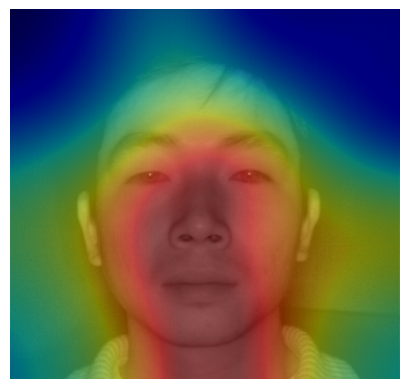

In [7]:
# %% Import necessary libraries for Grad-CAM
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

# Grad-CAM Class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None

        # Hooks to capture gradients and features
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.to(device)

        # Forward pass
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output)

        # Backward pass for the predicted class
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        # Pool the gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.features.size(1)):
            self.features[0, i, :, :] *= pooled_gradients[i]

        # Generate heatmap
        heatmap = torch.mean(self.features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

# %% Preprocess an input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Resize to match model input
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    image = Image.open(image_path).convert("RGB")  # Ensure 3-channel RGB
    input_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return input_tensor, image

# %% Overlay Grad-CAM heatmap on the original image
def overlay_heatmap(img, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((img.width, img.height), Image.Resampling.LANCZOS)
    heatmap = np.array(heatmap)

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay heatmap with transparency
    plt.axis('off')
    plt.show()

# %% Load the trained model
# Ensure the target layer is set correctly (layer4[-1] for ResNet)
model = ResNetWithAttention(num_classes=num_classes).to(device)
model.load_state_dict(torch.load("attention_mechanism_spatial.pth", map_location=device))
model.eval()

# Define the target layer for Grad-CAM (last layer of layer4 block)
target_layer = model.backbone.layer4[-1]
grad_cam = GradCAM(model, target_layer)

# %% Generate and visualize Grad-CAM heatmap
def generate_gradcam(image_path):
    # Preprocess the image
    input_tensor, original_image = preprocess_image(image_path)

    # Generate Grad-CAM heatmap
    heatmap = grad_cam(input_tensor)

    # Overlay the heatmap on the original image
    overlay_heatmap(original_image, heatmap)

# %% Test the Grad-CAM implementation
image_path = "001.bmp"  # Replace with your test image path
generate_gradcam(image_path)


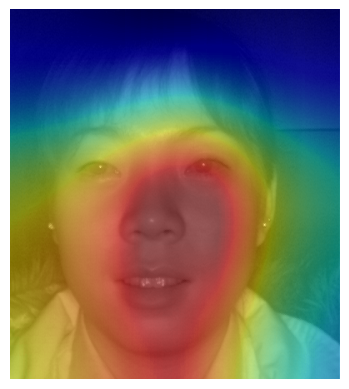

In [8]:
# Test the Grad-CAM implementation
image_path = "combined_dataset\\00182\\003.bmp"  # Replace with the path to your image
generate_gradcam(image_path)

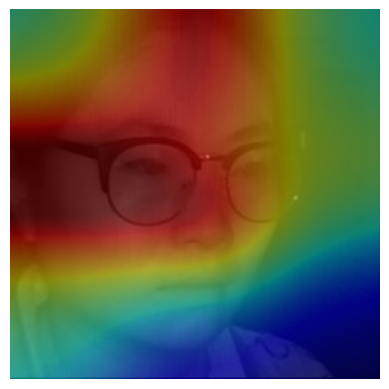

In [9]:
# Preprocess the input image
image_path = "LAMPHQ\\P0046\\NIR_P0046_1_LEFT_b.jpg"  # Path to the NIR image
generate_gradcam(image_path)

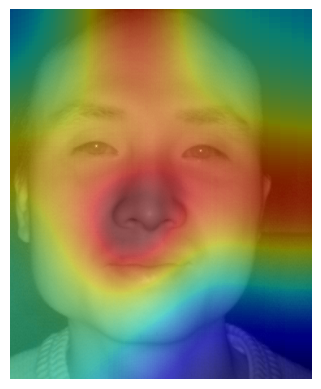

In [10]:
# Preprocess the input image
image_path = "combined_dataset\\00003\\001.bmp"  # Path to the NIR image
generate_gradcam(image_path)

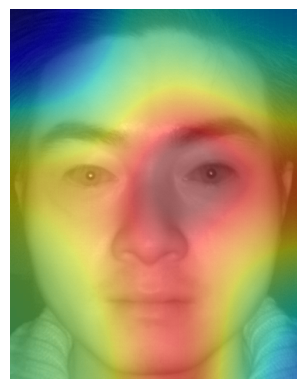

In [11]:
# Preprocess the input image 
image_path = "combined_dataset\\00046\\003.bmp"  # Path to the NIR image
generate_gradcam(image_path)